# Upload thre Zip File , what i find from Make sense [ This is a JSON file ]

In [1]:
from google.colab import files
uploaded = files.upload()  # select the COCO json file


Saving labels_my-project-name_2025-09-26-08-46-49.json to labels_my-project-name_2025-09-26-08-46-49.json


#Convert COCO JSON to  YOLO Segmentation

In [2]:
import json
import os

# Use the real file name from your upload
coco_file = "labels_my-project-name_2025-09-26-08-46-49.json"
output_folder = "clothing_anotation_task_dataset/Clothing_Anotation_Task/yolo_format"
os.makedirs(output_folder, exist_ok=True)

# Label mapping
class_map = {
    "full_sleeve": 0,
    "half_sleeve": 1,
    "pants_full": 2
}

# Load COCO JSON
with open(coco_file) as f:
    coco = json.load(f)

# Build image lookup
images = {img["id"]: img for img in coco["images"]}

# Process each annotation
for ann in coco["annotations"]:
    image_id = ann["image_id"]
    image_info = images[image_id]
    h, w = image_info["height"], image_info["width"]
    file_name = image_info["file_name"]

    # YOLO txt path
    txt_name = os.path.splitext(file_name)[0] + ".txt"
    txt_path = os.path.join(output_folder, txt_name)

    # Get category ID → label
    cat_id = ann["category_id"]
    cat_name = [c["name"] for c in coco["categories"] if c["id"] == cat_id][0]
    class_id = class_map[cat_name]

    # Segmentation points (flatten list)
    seg = ann["segmentation"][0]
    coords = []
    for i in range(0, len(seg), 2):
        x, y = seg[i], seg[i+1]
        coords.append(str(x / w))
        coords.append(str(y / h))

    line = f"{class_id} " + " ".join(coords)

    # Append to file
    with open(txt_path, "a") as f:
        f.write(line + "\n")

print("✅ Converted COCO annotations to YOLO segmentation format")


✅ Converted COCO annotations to YOLO segmentation format


# Verify .txt Annotations

In [3]:
import glob

txts = glob.glob(output_folder + "/*.txt")
print(f"📑 Found {len(txts)} YOLO annotation files")
print(txts[:5])  # show a few


📑 Found 30 YOLO annotation files
['clothing_anotation_task_dataset/Clothing_Anotation_Task/yolo_format/img_17.txt', 'clothing_anotation_task_dataset/Clothing_Anotation_Task/yolo_format/img_15.txt', 'clothing_anotation_task_dataset/Clothing_Anotation_Task/yolo_format/img_16.txt', 'clothing_anotation_task_dataset/Clothing_Anotation_Task/yolo_format/img_9.txt', 'clothing_anotation_task_dataset/Clothing_Anotation_Task/yolo_format/img_19.txt']


# the real folder + file names

In [5]:
import os

for root, dirs, files in os.walk("clothing_anotation_task_dataset/Clothing_Anotation_Task"):
    print("-", root)
    for f in files[:5]:
        print("   -", f)


- clothing_anotation_task_dataset/Clothing_Anotation_Task
- clothing_anotation_task_dataset/Clothing_Anotation_Task/yolo_format
   - img_17.txt
   - img_15.txt
   - img_16.txt
   - img_9.txt
   - img_19.txt


# Upload that image folder (zipped) to Colab: [ it consist od 30 Images ]

In [6]:
from google.colab import files
uploaded = files.upload()  # select your images.zip


Saving images_file.zip to images_file.zip


# Extract them to separate folders

In [7]:
import zipfile

for filename in uploaded.keys():
    foldername = filename.split('.')[0].replace(' ', '_').lower() + "_dataset"
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall(foldername)
    print(f"Extracted {filename} to {foldername}")

Extracted images_file.zip to images_file_dataset


# Inspect extracted folders

In [8]:
import os

# Automatically list all *_dataset folders
dataset_folders = [d for d in os.listdir() if d.endswith('_dataset') and os.path.isdir(d)]

for folder in dataset_folders:
    print(f"\n Inspecting: {folder}")
    for root, dirs, files in os.walk(folder):
        print("-", root)
        for file in files[:5]:
            print("   -", file)



 Inspecting: clothing_anotation_task_dataset
- clothing_anotation_task_dataset
- clothing_anotation_task_dataset/Clothing_Anotation_Task
- clothing_anotation_task_dataset/Clothing_Anotation_Task/yolo_format
   - img_17.txt
   - img_15.txt
   - img_16.txt
   - img_9.txt
   - img_19.txt

 Inspecting: images_file_dataset
- images_file_dataset
- images_file_dataset/images_file
   - img_22.jpg
   - img_6.jpg
   - img_28.jpg
   - img_5.jpg
   - img_26.jpg


# Unzip them into the same dataset folder where my labels are: ----

In [9]:
import zipfile, os

zip_path = "images_file.zip"   # replace with my actual uploaded filename
extract_path = "clothing_anotation_task_dataset/Clothing_Anotation_Task/Images"

os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Images extracted to", extract_path)


Images extracted to clothing_anotation_task_dataset/Clothing_Anotation_Task/Images


# Verify the extracted images

In [11]:
import glob

img_folder = "clothing_anotation_task_dataset/Clothing_Anotation_Task/Images"
all_images = glob.glob(img_folder + "/**/*.jpg", recursive=True)

print(f"Found {len(all_images)} images")
print(all_images[:10])  # show first 10


Found 30 images
['clothing_anotation_task_dataset/Clothing_Anotation_Task/Images/images_file/img_22.jpg', 'clothing_anotation_task_dataset/Clothing_Anotation_Task/Images/images_file/img_6.jpg', 'clothing_anotation_task_dataset/Clothing_Anotation_Task/Images/images_file/img_28.jpg', 'clothing_anotation_task_dataset/Clothing_Anotation_Task/Images/images_file/img_5.jpg', 'clothing_anotation_task_dataset/Clothing_Anotation_Task/Images/images_file/img_26.jpg', 'clothing_anotation_task_dataset/Clothing_Anotation_Task/Images/images_file/img_4.jpg', 'clothing_anotation_task_dataset/Clothing_Anotation_Task/Images/images_file/img_24.jpg', 'clothing_anotation_task_dataset/Clothing_Anotation_Task/Images/images_file/img_11.jpg', 'clothing_anotation_task_dataset/Clothing_Anotation_Task/Images/images_file/img_14.jpg', 'clothing_anotation_task_dataset/Clothing_Anotation_Task/Images/images_file/img_29.jpg']


# Check consistency with labels

In [13]:
import os

label_folder = "clothing_anotation_task_dataset/Clothing_Anotation_Task/yolo_format"

# Strip extensions
img_names = {os.path.splitext(os.path.basename(f))[0] for f in all_images}
label_names = {os.path.splitext(os.path.basename(f))[0] for f in glob.glob(label_folder + "/*.txt")}

print("Images:", len(img_names))
print("Labels:", len(label_names))
print("Common:", len(img_names & label_names))
print("Images without labels:", img_names - label_names)
print("Labels without images:", label_names - img_names)


Images: 30
Labels: 30
Common: 30
Images without labels: set()
Labels without images: set()


# Creating A YOLO structre

In [14]:
import os

base = "dataset"  # new dataset folder
os.makedirs(f"{base}/images/train", exist_ok=True)
os.makedirs(f"{base}/images/val", exist_ok=True)
os.makedirs(f"{base}/labels/train", exist_ok=True)
os.makedirs(f"{base}/labels/val", exist_ok=True)

print("✅ YOLO folder structure created")


✅ YOLO folder structure created


# Split Images + Labels into Train/Val

In [15]:
import glob, shutil
from sklearn.model_selection import train_test_split

# Paths
img_folder = "clothing_anotation_task_dataset/Clothing_Anotation_Task/Images"
label_folder = "clothing_anotation_task_dataset/Clothing_Anotation_Task/yolo_format"

# Get all images
images = glob.glob(img_folder + "/**/*.jpg", recursive=True)
print(f"Found {len(images)} images for splitting")

# Split
train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

def move_files(img_list, split):
    for img_path in img_list:
        file = os.path.basename(img_path)
        name, _ = os.path.splitext(file)

        # Move image
        shutil.copy(img_path, f"{base}/images/{split}/{file}")

        # Move label
        label_path = os.path.join(label_folder, name + ".txt")
        if os.path.exists(label_path):
            shutil.copy(label_path, f"{base}/labels/{split}/{name}.txt")

move_files(train_imgs, "train")
move_files(val_imgs, "val")

print(f"Moved {len(train_imgs)} train and {len(val_imgs)} val images+labels")


Found 30 images for splitting
Moved 24 train and 6 val images+labels


# Write a proper data.yaml (don’t paste YAML into a Python cell)

In [16]:
# create dataset/data.yaml correctly
yaml_content = """train: dataset/images/train
val: dataset/images/val

nc: 3
names: ['full_sleeve', 'half_sleeve', 'pants_full']
"""

with open("dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("dataset/data.yaml created at ./dataset/data.yaml")


dataset/data.yaml created at ./dataset/data.yaml


# Install Ultralytics YOLOv8 (Colab)

In [17]:
!pip install -U ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.0 MB/s eta 0:00:00


# Before running, checking the paths

In [18]:
!ls dataset/images/train | head -5
!ls dataset/images/val | head -5


img_10.jpg
img_11.jpg
img_13.jpg
img_15.jpg
img_16.jpg
img_12.jpg
img_14.jpg
img_18.jpg
img_27.jpg
img_29.jpg


# Rewrite data.yaml with correct paths

In [19]:
yaml_content = """train: images/train
val: images/val

nc: 3
names: ['full_sleeve', 'half_sleeve', 'pants_full']
"""
with open("dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("Fixed dataset/data.yaml created")


Fixed dataset/data.yaml created


# Train a YOLOv8 segmentation model

In [20]:
from ultralytics import YOLO

# Load YOLOv8 segmentation model (nano = lightweight)
model = YOLO("yolov8n-seg.pt")

# Train
model.train(
    data="dataset/data.yaml",  # dataset config
    epochs=30,                 # number of epochs
    imgsz=640,                 # input size
    batch=4,                   # reduce if out of memory
    project="runs/seg",        # results folder
    name="cloth_seg_run"       # experiment name
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d2f40fb36e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04

# Find the latest run & the best weights

In [21]:
# 1_a. Find latest runs/seg/* folder (where training outputs are saved)
import glob, os, sys
runs = sorted(glob.glob("runs/seg/*"), key=os.path.getmtime)
if not runs:
    raise SystemExit("No runs found in runs/seg/. Did training finish?")

run = runs[-1]  # latest run folder
print("Latest run folder:", run)

# 1_b. Locate weights (best.pt or last.pt)
weights_dir = os.path.join(run, "weights")
best_w = os.path.join(weights_dir, "best.pt")
last_w = os.path.join(weights_dir, "last.pt")

if os.path.exists(best_w):
    weights_path = best_w
elif os.path.exists(last_w):
    weights_path = last_w
else:
    # try any .pt in weights_dir
    pt_files = glob.glob(os.path.join(weights_dir, "*.pt"))
    if pt_files:
        weights_path = pt_files[-1]
    else:
        raise SystemExit(f"No .pt weights found in {weights_dir}")

print("Using weights:", weights_path)

# 1_c. Show available useful files
for fname in ["results.png", "results.txt"]:
    p = os.path.join(run, fname)
    if os.path.exists(p):
        print("Found:", p)


Latest run folder: runs/seg/cloth_seg_run
Using weights: runs/seg/cloth_seg_run/weights/best.pt
Found: runs/seg/cloth_seg_run/results.png


# Display training plots (loss / metrics) inline

Displaying training curves:


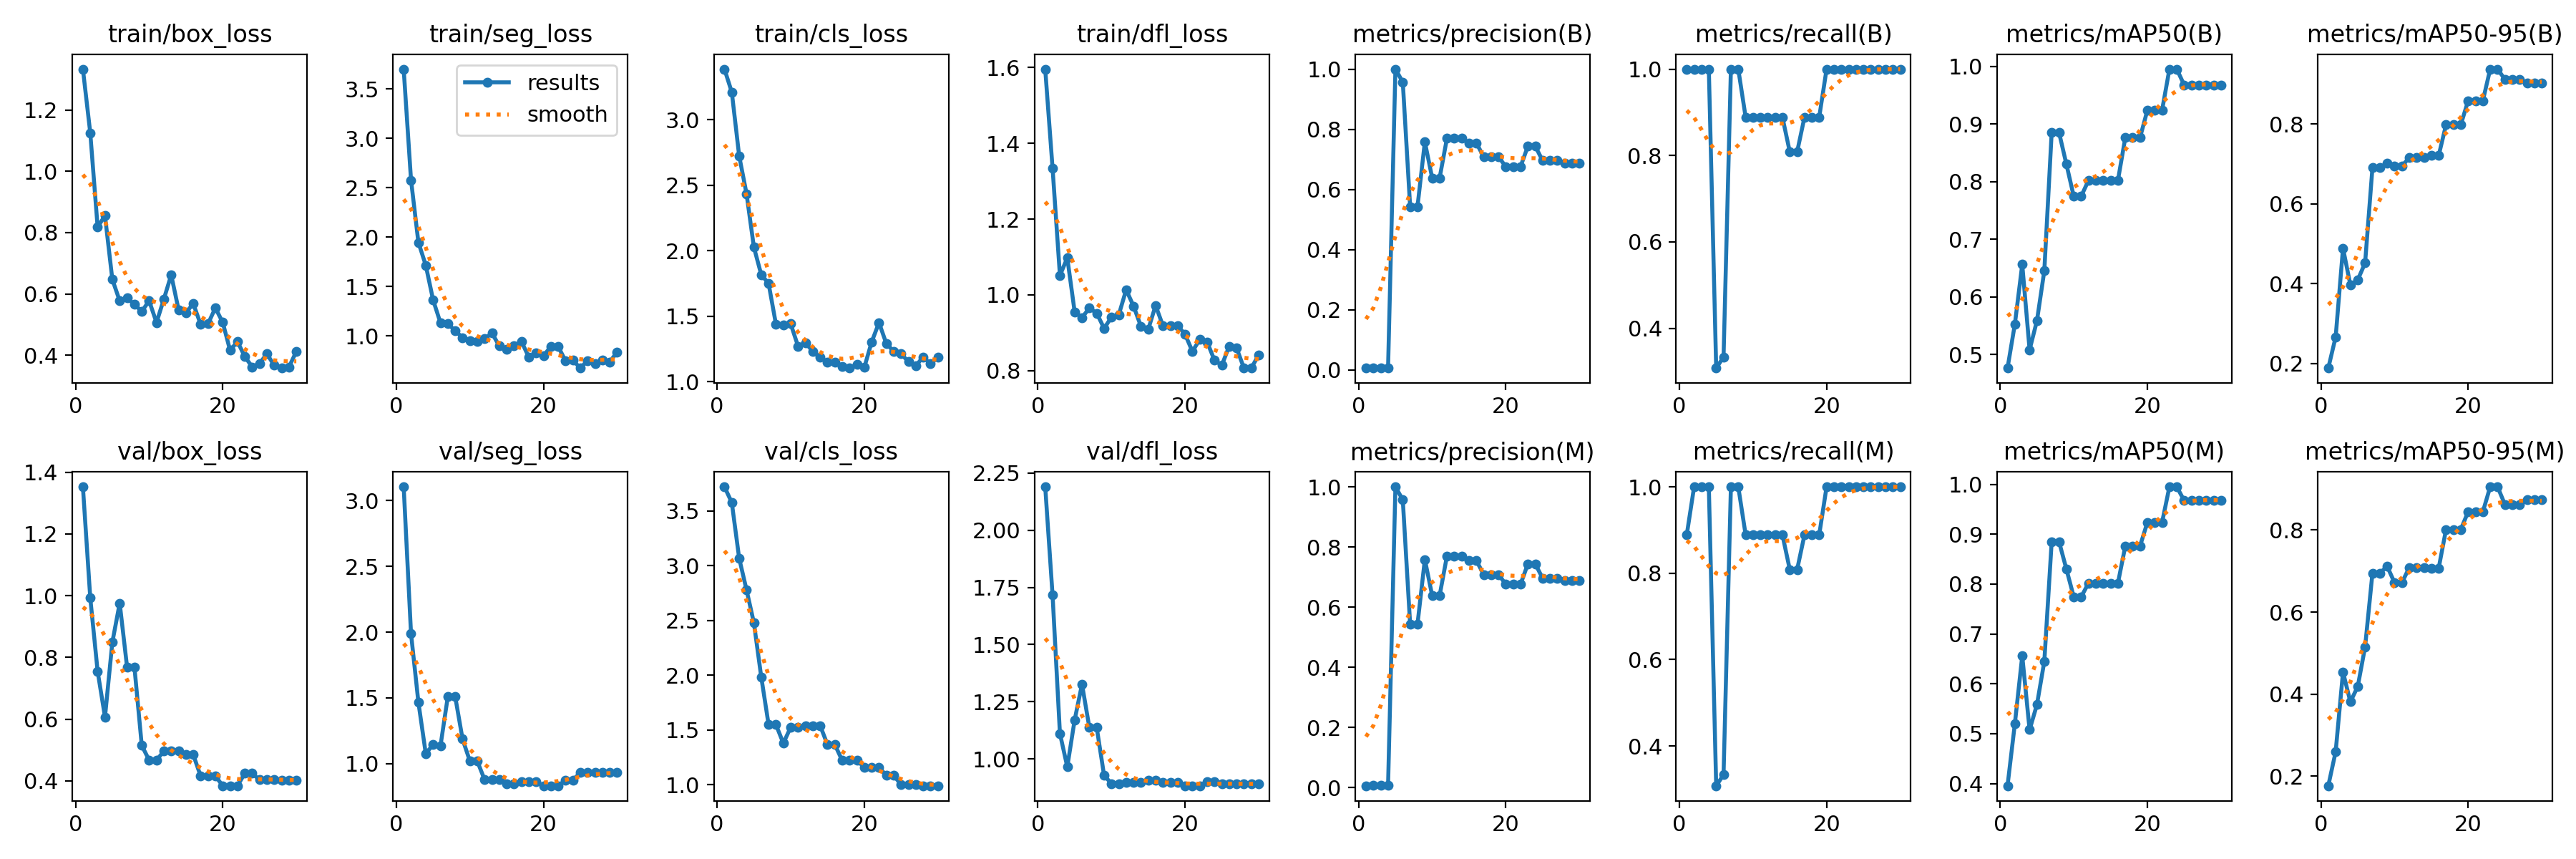

In [22]:
from IPython.display import Image, display
import matplotlib.pyplot as plt
import os

results_png = os.path.join(run, "results.png")
if os.path.exists(results_png):
    print("Displaying training curves:")
    display(Image(results_png))
else:
    print("No results.png found in run folder:", run)


# Run inference on the validation set (save predictions)

In [24]:
from ultralytics import YOLO
import glob, os, shutil

# Load best weights
model = YOLO(weights_path)

# Predict on validation folder and save output images with masks overlaid
# conf threshold can be adjusted; save=True writes images to a predict folder
pred_res = model.predict(source="dataset/images/val", conf=0.25, imgsz=640, save=True)

# Find the most recent predict folder under runs/seg
predict_folders = sorted(glob.glob("runs/seg/*/predict"), key=os.path.getmtime)
if predict_folders:
    predict_folder = predict_folders[-1]
    print("Predictions saved to:", predict_folder)
else:
    # some ultralytics versions save to runs/segment/predict or runs/seg/predict
    alt = glob.glob("runs/**/predict", recursive=True)
    predict_folder = alt[-1] if alt else None
    print("Alternative predict folder:", predict_folder)

# Show a few predicted images file paths
if predict_folder:
    preds = glob.glob(os.path.join(predict_folder, "*"))
    print("Example predicted files:", preds[:6])
else:
    print("No predict folder found. Check model.predict() output.")



image 1/6 /content/dataset/images/val/img_12.jpg: 640x320 1 half_sleeve, 1 pants_full, 282.4ms
image 2/6 /content/dataset/images/val/img_14.jpg: 640x384 1 full_sleeve, 1 half_sleeve, 1 pants_full, 333.7ms
image 3/6 /content/dataset/images/val/img_18.jpg: 640x320 1 half_sleeve, 1 pants_full, 367.4ms
image 4/6 /content/dataset/images/val/img_2.jpg: 640x320 1 full_sleeve, 1 half_sleeve, 1 pants_full, 592.0ms
image 5/6 /content/dataset/images/val/img_27.jpg: 640x448 1 full_sleeve, 1 half_sleeve, 1 pants_full, 361.4ms
image 6/6 /content/dataset/images/val/img_29.jpg: 640x448 1 half_sleeve, 1 pants_full, 353.5ms
Speed: 4.9ms preprocess, 381.7ms inference, 17.2ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/segment/predict
Alternative predict folder: runs/segment/predict
Example predicted files: ['runs/segment/predict/img_14.jpg', 'runs/segment/predict/img_29.jpg', 'runs/segment/predict/img_12.jpg', 'runs/segment/predict/img_18.jpg', 'runs/segment/predict/im

# Visualize a few predicted images inline

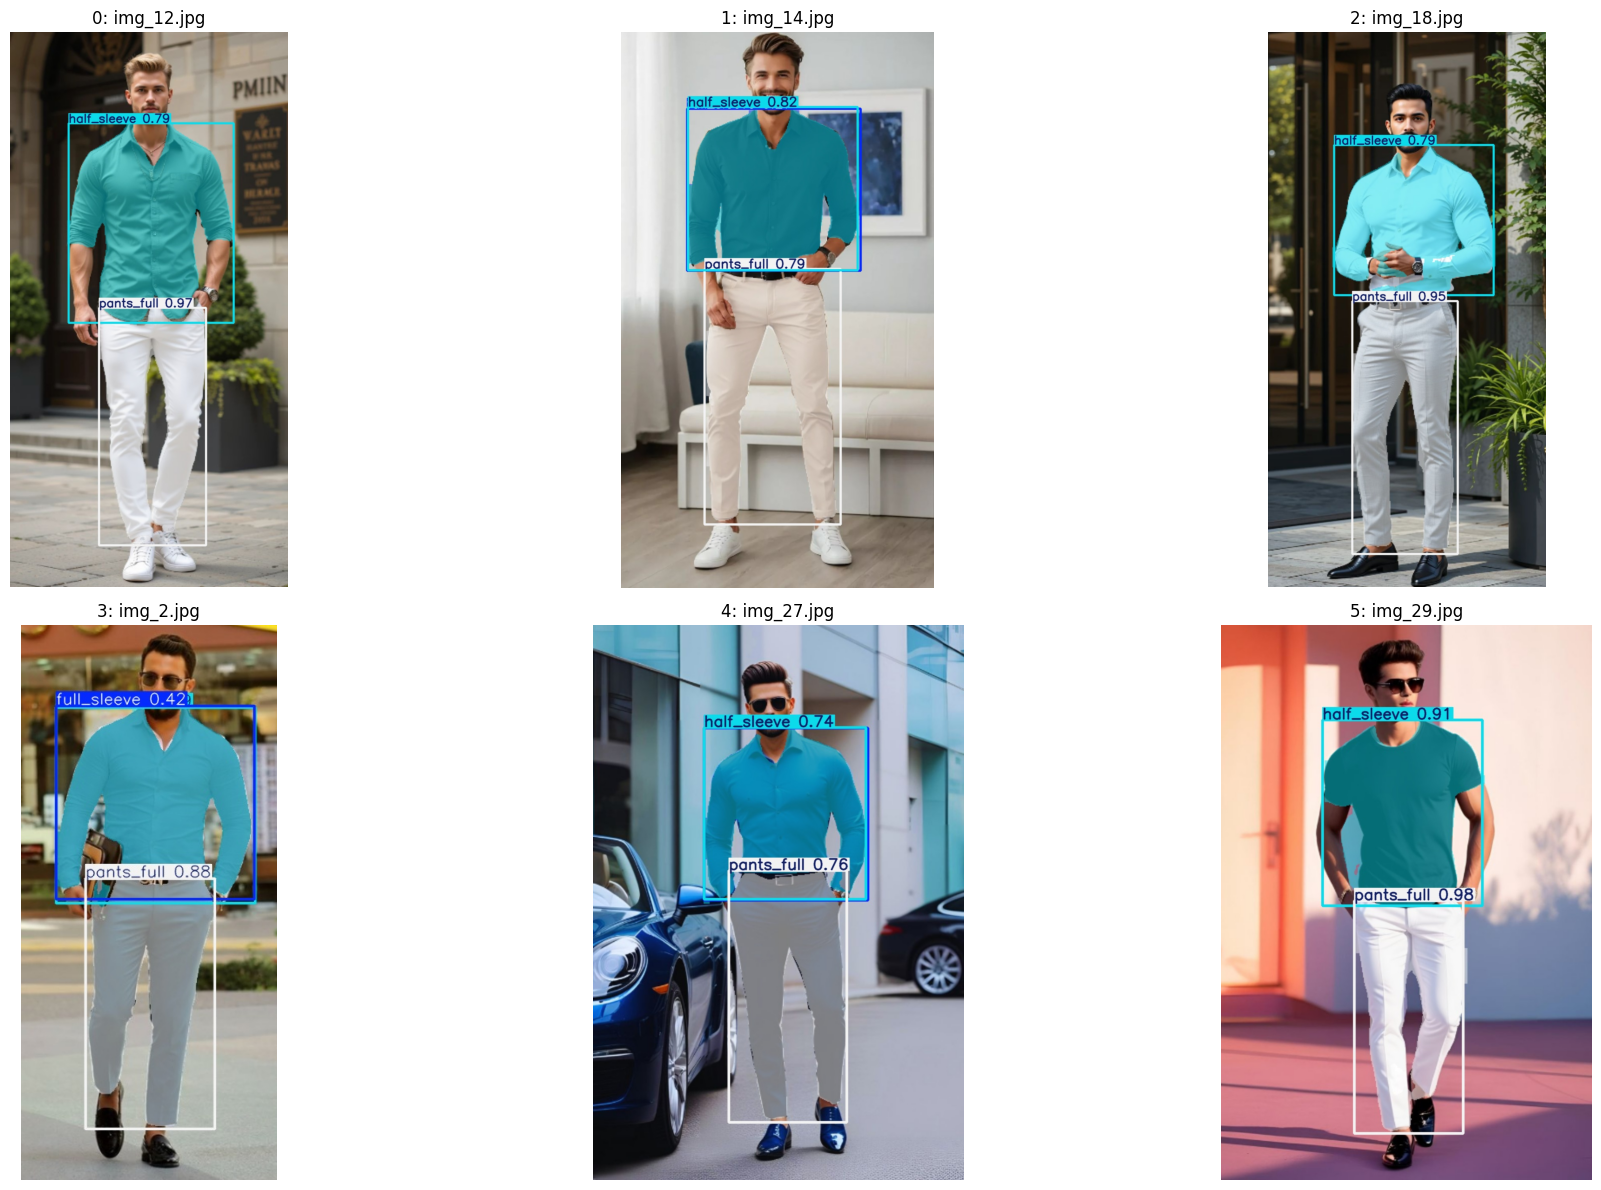

In [25]:
import matplotlib.pyplot as plt
import cv2
import glob, os

if predict_folder and os.path.exists(predict_folder):
    all_imgs = sorted(glob.glob(os.path.join(predict_folder, "*")))
    if not all_imgs:
        print("No files in predict folder.")
    else:
        cols = 3
        batch_size = 6  # number of images per page

        for start_idx in range(0, len(all_imgs), batch_size):
            sample_imgs = all_imgs[start_idx:start_idx+batch_size]
            rows = (len(sample_imgs) + cols - 1) // cols
            plt.figure(figsize=(7*cols, 6*rows))

            for i, p in enumerate(sample_imgs):
                img = cv2.imread(p)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                plt.subplot(rows, cols, i+1)
                plt.imshow(img)
                plt.title(f"{start_idx+i}: {os.path.basename(p)}")  # index + name
                plt.axis("off")

            plt.tight_layout()
            plt.show()
else:
    print("predict_folder not available for visualization.")
